In [1]:
# ─────────────────────────────────────────────
# [C1] Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 모든 import를 여기 모읍니다 (순서 실행 안전)
# ─────────────────────────────────────────────
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.datasets import make_blobs, make_moons, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import silhouette_score, silhouette_samples

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import matplotlib.font_manager as fm

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True, capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])
print("준비 완료 ✓")

준비 완료 ✓


In [2]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터 실습 데이터 준비 — 합성 3종 + 실데이터 1종
# (실행하면 네 데이터의 크기와 고객 데이터 요약이 출력됩니다)
# ─────────────────────────────────────────────
# (A) 깔끔한 군집 4개 — K-Means·실루엣 연습용
X_blob, y_blob = make_blobs(n_samples=500, centers=4, cluster_std=1.0,
                            random_state=RANDOM_STATE)
# (B) 초승달 2개 — DBSCAN이 빛나는 비구형
X_moon, _ = make_moons(n_samples=400, noise=0.06, random_state=RANDOM_STATE)

# (C) 펭귄 실데이터 — 실루엣을 실데이터에서 확인할 때
# seaborn 내장 데이터셋을 내려받아 씁니다 (첫 실행 시 인터넷 연결이 필요합니다)
peng = sns.load_dataset("penguins")
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
peng = peng.dropna(subset=num_cols).reset_index(drop=True)


# (D) 모두플레이 구독자 데이터 — 오늘의 메인. 세그먼트 해석과 피처화에 씁니다
def make_moduplay_customers(n=1200, seed=RANDOM_STATE):
    """모두플레이 구독자 데이터를 만듭니다. 3개 세그먼트 구조를 심어 둡니다.

    열 이름은 지난 시간들과 같습니다 — 실무에서는 pd.read_csv 자리입니다.
    시드를 고정했으니 결과가 항상 같습니다.
    """
    rng = np.random.default_rng(seed)
    seg = rng.choice([0, 1, 2], n, p=[0.45, 0.30, 0.25])
    #        (지난달 시청 시간, 월 세션 수, 마지막 시청 후 경과일)
    center = {0: (9, 2.2, 20), 1: (44, 9.5, 2), 2: (25, 5.5, 48)}
    # 음수가 나오지 않게 최솟값을 눌러 둡니다 (시청 시간·세션 수·경과일은 음수가 될 수 없습니다)
    watch = np.clip(np.array([center[s][0] for s in seg]) + rng.normal(0, 4.0, n), 0.2, None)
    sess = np.clip(np.array([center[s][1] for s in seg]) + rng.normal(0, 1.0, n), 0, None)
    recency = np.clip(np.array([center[s][2] for s in seg]) + rng.normal(0, 6.0, n), 0, None)
    # 이탈은 '세그먼트 정체성'이 좌우합니다 (선형으로 잡기 어려운 구조)
    churn_rate = {0: 0.18, 1: 0.06, 2: 0.55}
    churn = rng.binomial(1, [churn_rate[s] for s in seg])
    return pd.DataFrame({
        "watch_hours_last_month": watch.round(1),   # 지난달 시청 시간
        "sessions_per_month": sess.round(2),        # 월 시청 세션 수
        "days_since_last_watch": recency.round(0),  # 마지막 시청 후 경과일
        "churn": churn,                             # 이탈 여부 (Part 7에서만 씁니다)
    })


cust = make_moduplay_customers()
CUST_FEAT = ["watch_hours_last_month", "sessions_per_month", "days_since_last_watch"]

print(f"(A) make_blobs {X_blob.shape}  (B) make_moons {X_moon.shape}  (C) penguins {peng.shape}")
print(f"(D) 모두플레이 구독자 {cust.shape}  이탈률 {cust['churn'].mean():.3f}")
print()
print(cust[CUST_FEAT].describe().round(1).to_string())
print()
print("→ 합성 데이터는 '정답 구조'를 알고 만들지만, 군집 알고리즘에는 정답 없이 X만 줍니다.")
print("  고객 데이터의 churn은 Part 7까지 쓰지 않습니다 — 지금은 정답이 없는 셈입니다.")

(A) make_blobs (500, 2)  (B) make_moons (400, 2)  (C) penguins (342, 7)
(D) 모두플레이 구독자 (1200, 4)  이탈률 0.241

       watch_hours_last_month  sessions_per_month  days_since_last_watch
count                  1200.0              1200.0                 1200.0
mean                     23.1                 5.2                   22.4
std                      15.3                 3.2                   17.5
min                       0.2                 0.0                    0.0
25%                       9.5                 2.4                    7.8
50%                      21.4                 4.6                   19.0
75%                      39.1                 8.5                   38.0
max                      55.7                12.6                   65.0

→ 합성 데이터는 '정답 구조'를 알고 만들지만, 군집 알고리즘에는 정답 없이 X만 줍니다.
  고객 데이터의 churn은 Part 7까지 쓰지 않습니다 — 지금은 정답이 없는 셈입니다.


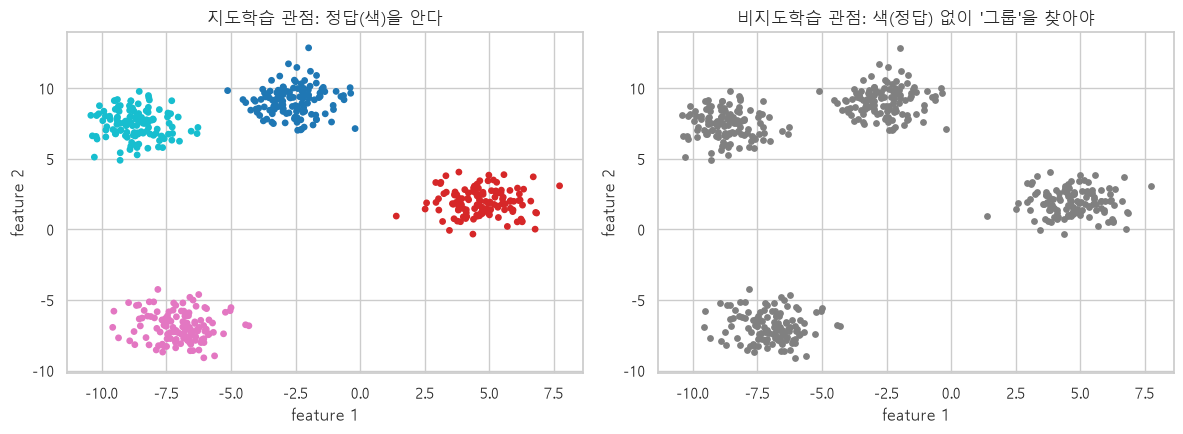

→ 오른쪽처럼 '정답 색이 없는' 회색 점들에서, 알고리즘이 스스로 그룹을 찾는 게 군집화입니다.


In [3]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 같은 데이터, 다른 시작점 [도식] 지도(정답 색칠) vs 비지도(색 없음) — 같은 데이터, 다른 시작점
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap="tab10", s=15)
axes[0].set_title("지도학습 관점: 정답(색)을 안다")
axes[1].scatter(X_blob[:, 0], X_blob[:, 1], c="gray", s=15)
axes[1].set_title("비지도학습 관점: 색(정답) 없이 '그룹'을 찾아야")
for ax in axes: ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout(); plt.show()
print("→ 오른쪽처럼 '정답 색이 없는' 회색 점들에서, 알고리즘이 스스로 그룹을 찾는 게 군집화입니다.")

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\tjwls\anaconda3\envs\myenv\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\tjwls\anaconda3\envs\myenv\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\tjwls\anaconda3\envs\myenv\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


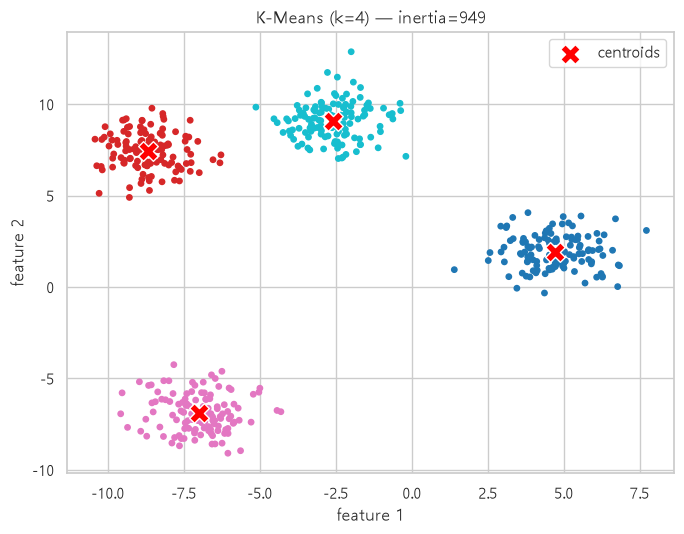

→ 빨간 X가 각 군집의 '중심'입니다. 정답 색 없이도 네 덩어리를 잘 찾아냈습니다.


In [4]:
# ─────────────────────────────────────────────
# [C4] Part 2 · 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기 K-Means로 make_blobs를 군집화 (정답 없이 X만 준다)
# ─────────────────────────────────────────────
km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
labels = km.fit_predict(X_blob)        # 각 점의 군집 번호(0~3)

plt.figure(figsize=(7, 5.5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="tab10", s=15)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="red", marker="X", s=200, edgecolor="white", label="centroids")
plt.title(f"K-Means (k=4) — inertia={km.inertia_:.0f}")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.legend()
plt.tight_layout(); plt.show()
print("→ 빨간 X가 각 군집의 '중심'입니다. 정답 색 없이도 네 덩어리를 잘 찾아냈습니다.")

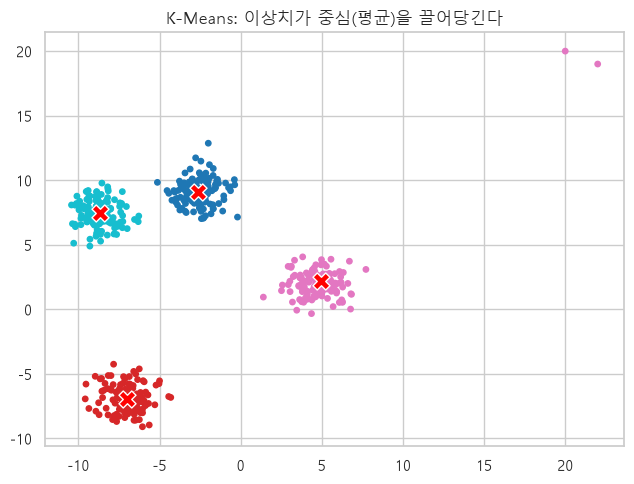

→ K-Means는 '평균'으로 중심을 잡아 이상치에 민감합니다. DBSCAN은 설정한 밀도 기준에 따라 이런 점을 잡음 후보로 분리할 수 있습니다.


In [5]:
# [C5] Part 2 · 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기 K-Means의 약점 — 이상치에 끌려가는 중심
import numpy as np
X_out = np.vstack([X_blob, [[20, 20], [22, 19]]])    # 멀리 떨어진 이상치 2개 추가
lb_out = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_out)
plt.figure(figsize=(6.5, 5))
plt.scatter(X_out[:, 0], X_out[:, 1], c=lb_out.labels_, cmap="tab10", s=15)
plt.scatter(lb_out.cluster_centers_[:, 0], lb_out.cluster_centers_[:, 1], c="red", marker="X", s=150, edgecolor="white")
plt.title("K-Means: 이상치가 중심(평균)을 끌어당긴다")
plt.tight_layout(); plt.show()
print("→ K-Means는 '평균'으로 중심을 잡아 이상치에 민감합니다. DBSCAN은 설정한 밀도 기준에 따라 이런 점을 잡음 후보로 분리할 수 있습니다.")

👀 [C5] 결과읽기
두 극단값이 평균인 중심을 끌어당깁니다. 이 그림은 K-Means가 이상값에 민감할 수 있음을 보여 주지만, DBSCAN의 잡음 판정이 곧 업무상 이상 거래 판정이라는 뜻은 아닙니다.

K-Means가 "수렴"한다는 것
K-Means는 배정 → 중심 이동을 반복하다 더 이상 배정이 바뀌지 않으면 멈춥니다(수렴). 매 반복마다 inertia(군집 내 거리 제곱합)가 줄어들도록 보장돼 있어, 언젠가는 멈춥니다. 다만 전역 최적이 아니라 지역 최적에 멈출 수 있어(초기값 의존), n_init로 여러 번 시도해 가장 좋은 결과를 택합니다. [C6]에서 반복 횟수에 따라 중심이 이동하는 모습을 확인합니다.

[문제]
1) `KMeans`의 `n_clusters`를 3과 6으로 바꿔 `X_blob`(정답은 4군집)을 각각 군집화해확인합니다.
2) 두 결과를 산점도로 나란히 그려, 잘못된 k가 군집을 어떻게 왜곡하는지 관찰해확인합니다.

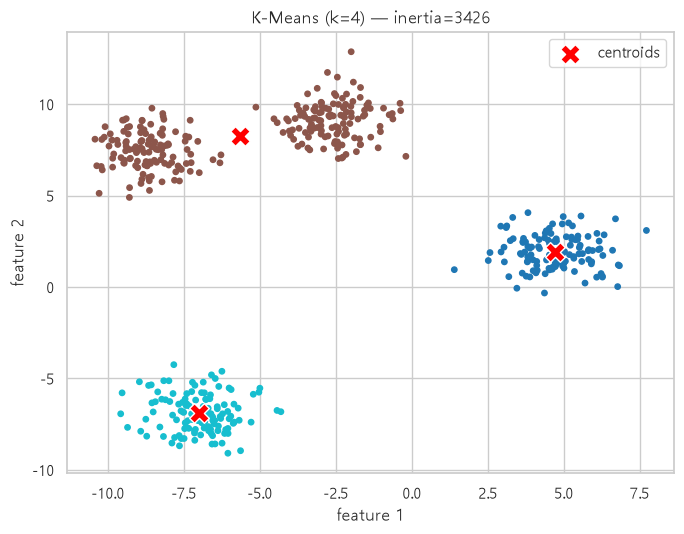

In [6]:
# [C7] Part 2 · ⌨️ 백문이 불여일타! (1) ⌨️ 백문이 불여일타! (1) — 잘못된 k(3, 6)로 군집화해 결과 비교

# 여기에 코드를 작성하세요
km = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels = km.fit_predict(X_blob)
plt.figure(figsize=(7, 5.5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="tab10", s=15)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="red", marker="X", s=200, edgecolor="white", label="centroids")
plt.title(f"K-Means (k=4) — inertia={km.inertia_:.0f}")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.legend()
plt.tight_layout(); plt.show()

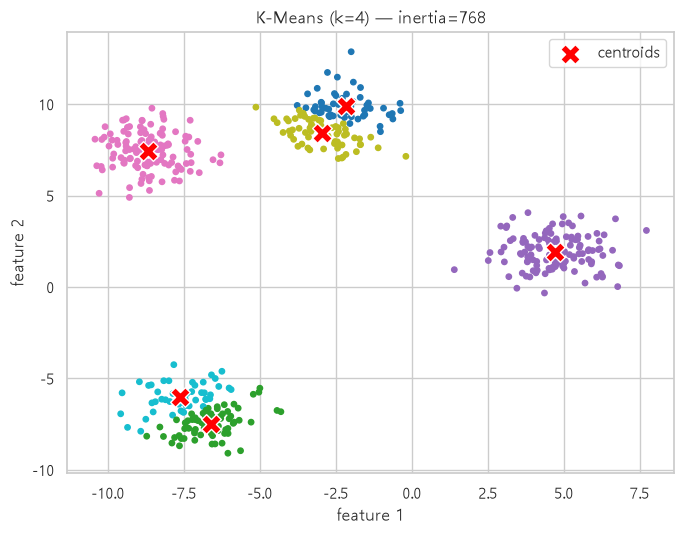

In [7]:
km = KMeans(n_clusters=6, n_init=10, random_state=RANDOM_STATE)
labels = km.fit_predict(X_blob)
plt.figure(figsize=(7, 5.5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="tab10", s=15)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="red", marker="X", s=200, edgecolor="white", label="centroids")
plt.title(f"K-Means (k=4) — inertia={km.inertia_:.0f}")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.legend()
plt.tight_layout(); plt.show()

잘못된 k가 군집을 못 찾아낼 수 있고, 군집을 세분화시킬 수도 있다.

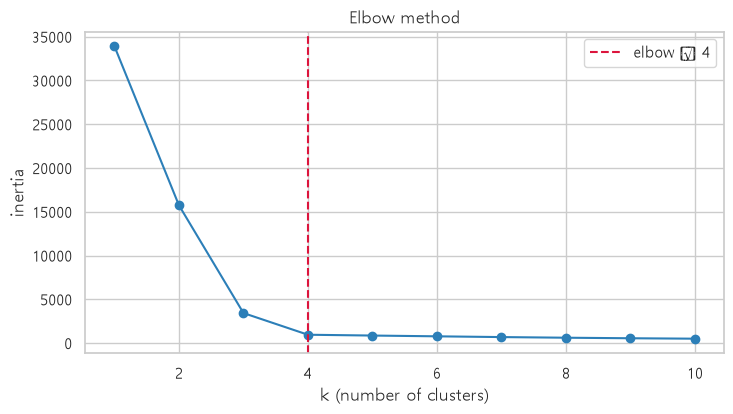

→ k=4 부근에서 '꺾임'이 보입니다. 그 뒤로는 k를 늘려도 inertia가 완만히 줄 뿐입니다.


In [8]:
# ─────────────────────────────────────────────
# [C8] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 Elbow — k에 따른 inertia
# ─────────────────────────────────────────────
ks = range(1, 11)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_blob).inertia_ for k in ks]
plt.figure(figsize=(7.5, 4.3))
plt.plot(list(ks), inertias, "o-", color="#2c7fb8")
plt.axvline(4, ls="--", color="crimson", label="elbow ≈ 4")
plt.xlabel("k (number of clusters)"); plt.ylabel("inertia")
plt.title("Elbow method"); plt.legend(); plt.tight_layout(); plt.show()
print("→ k=4 부근에서 '꺾임'이 보입니다. 그 뒤로는 k를 늘려도 inertia가 완만히 줄 뿐입니다.")

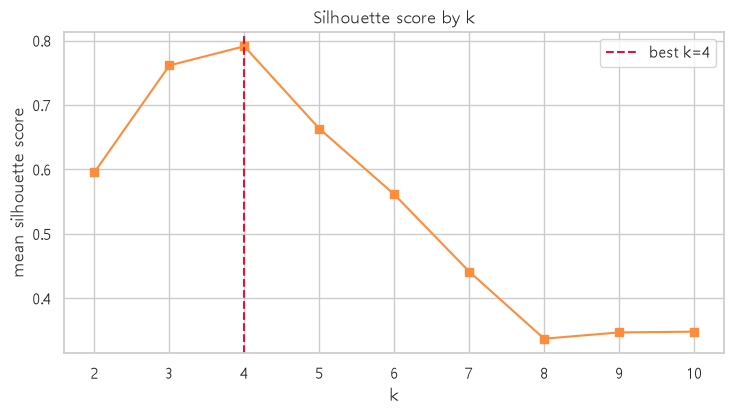

→ 실루엣 점수가 가장 높은 k=4. Elbow와 같은 k를 지지하지만 정답이 확정되는 것은 아닙니다.


In [9]:
# ─────────────────────────────────────────────
# [C9] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 Silhouette — k에 따른 평균 실루엣 점수
# ─────────────────────────────────────────────
sil = []
for k in range(2, 11):     # 실루엣은 k>=2
    lb = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_blob)
    sil.append(silhouette_score(X_blob, lb))
plt.figure(figsize=(7.5, 4.3))
plt.plot(range(2, 11), sil, "s-", color="#fd8d3c")
best_k = list(range(2, 11))[int(np.argmax(sil))]
plt.axvline(best_k, ls="--", color="crimson", label=f"best k={best_k}")
plt.xlabel("k"); plt.ylabel("mean silhouette score")
plt.title("Silhouette score by k"); plt.legend(); plt.tight_layout(); plt.show()
print(f"→ 실루엣 점수가 가장 높은 k={best_k}. Elbow와 같은 k를 지지하지만 정답이 확정되는 것은 아닙니다.")

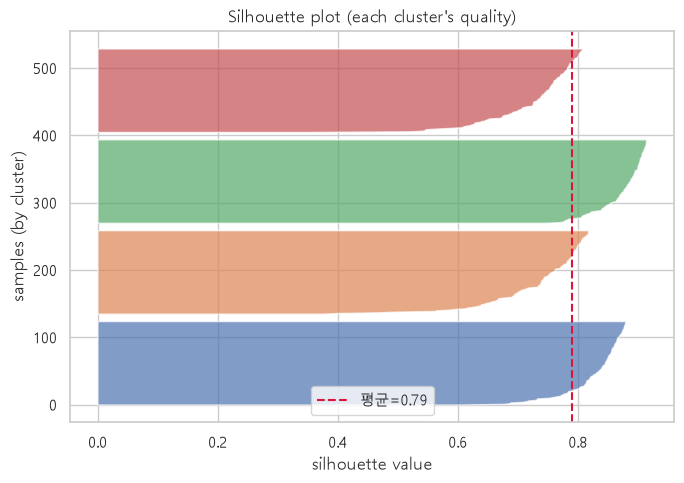

→ 각 군집의 실루엣 분포. 세로 길이는 군집 크기, 가로 길이는 점별 Silhouette입니다. 음수 값은 경계가 모호한 점을 뜻합니다.


In [10]:
# [C10] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 실루엣 플롯 — 군집별 품질 분포
labels4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_blob)
sv = silhouette_samples(X_blob, labels4)
fig, ax = plt.subplots(figsize=(7, 5)); y_low = 0
for i in range(4):
    vals = np.sort(sv[labels4 == i])
    ax.fill_betweenx(np.arange(y_low, y_low + len(vals)), 0, vals, alpha=0.7)
    y_low += len(vals) + 10
ax.axvline(sv.mean(), color="crimson", ls="--", label=f"평균={sv.mean():.2f}")
ax.set_xlabel("silhouette value"); ax.set_ylabel("samples (by cluster)")
ax.set_title("Silhouette plot (each cluster's quality)"); ax.legend()
plt.tight_layout(); plt.show()
print("→ 각 군집의 실루엣 분포. 세로 길이는 군집 크기, 가로 길이는 점별 Silhouette입니다. 음수 값은 경계가 모호한 점을 뜻합니다.")

[문제]
1) `make_blobs`의 `centers`를 5로 바꿔 새 데이터를 만듭니다.
2) 새 데이터로 k별 inertia(Elbow)와 Silhouette 점수를 다시 계산해, 두 지표가 k=5를 가리키는지 확인합니다.

In [ ]:
X_blob5, y_blob5 = make_blobs(n_samples=500, centers=5, cluster_std=1.0,
                               random_state=RANDOM_STATE)
#Elbow                          
ks = range(1, 11)
inertias5 = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_blob5).inertia_ for k in ks]
# Silhouette
sil5 = []
for k in range(2, 11):
    lb = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_blob5)
    sil5.append(silhouette_score(X_blob5, lb))
best_k5 = list(range(2, 11))[int(np.argmax(sil5))]

inertias5
best_k5
# 두 지표 모두 k=4를 가리킴

4

[문제]
1) 실데이터 `peng`(펭귄)의 수치 컬럼 4개를 `StandardScaler`로 표준화합니다.
2) k=2~6 각각 K-Means로 군집화해 실루엣 점수를 출력하고, 적정 k를 고릅니다.

In [17]:
# [C12] Part 3 · ⌨️ 백문이 불여일타! (3) ⌨️ 백문이 불여일타! (3) — penguins 실데이터에서 k별 실루엣 비교

# 여기에 코드를 작성하세요
scaler = StandardScaler()
X_peng = scaler.fit_transform(peng[num_cols]) 
# 2) k=2~6 K-Means + Silhouette
sil_peng = []
for k in range(2, 7):
    labels_p = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_peng)
    score = silhouette_score(X_peng, labels_p)
    sil_peng.append(score)
    print(f"k={k}  silhouette={score:.3f}")

best_k_peng = list(range(2, 7))[int(np.argmax(sil_peng))]

k=2  silhouette=0.532
k=3  silhouette=0.447
k=4  silhouette=0.400
k=5  silhouette=0.379
k=6  silhouette=0.368


최적 k = 2 (실루엣 점수가 k가 커질수록 계속 떨어지는 형태예요).

펭귄 데이터는 실제로 3개 종(Adelie, Chinstrap, Gentoo)이 섞여있는데도 실루엣은 k=2를 고른 이유:

Gentoo 종이 체구·부리 모양에서 나머지 두 종과 확연히 떨어져 있어서, "Gentoo vs 나머지 둘"이라는 큰 경계가 기하학적으로 가장 선명해요.
Adelie와 Chinstrap은 부리 모양은 다르지만 크기대가 겹쳐서 그 둘 사이 경계는 흐릿하고요.

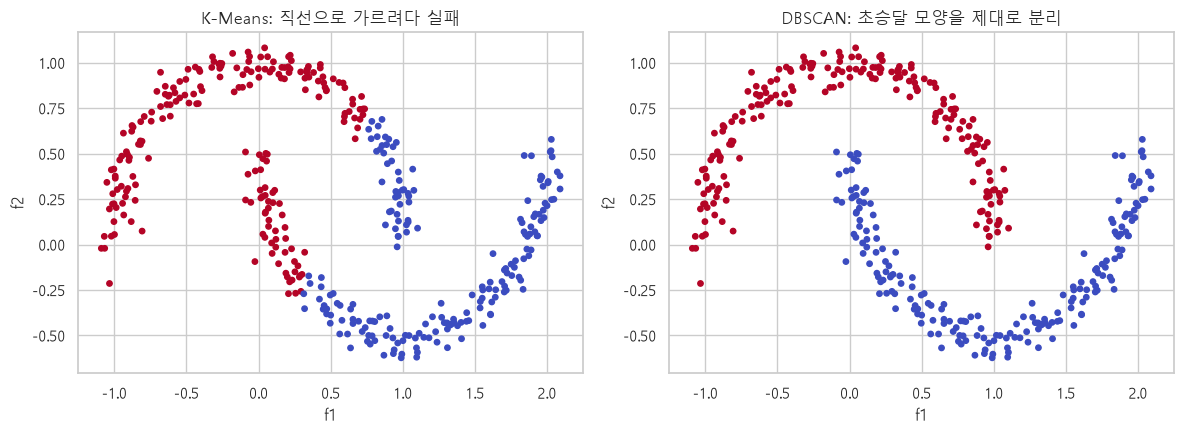

→ K-Means는 '둥근 군집' 가정 때문에 초승달을 가로질러 자릅니다. DBSCAN은 밀도로 따라가 성공.


In [18]:
# ─────────────────────────────────────────────
# [C13] Part 4 · 📊 데이터로 확인해 봅시다 — 초승달 데이터에서 두 알고리즘을 비교 K-Means vs DBSCAN — 초승달(make_moons)에서 누가 옳은가
# ─────────────────────────────────────────────
km_moon = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_moon)
db_moon = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moon)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=km_moon, cmap="coolwarm", s=15)
axes[0].set_title("K-Means: 직선으로 가르려다 실패")
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=db_moon, cmap="coolwarm", s=15)
axes[1].set_title("DBSCAN: 초승달 모양을 제대로 분리")
for ax in axes: ax.set_xlabel("f1"); ax.set_ylabel("f2")
plt.tight_layout(); plt.show()
print("→ K-Means는 '둥근 군집' 가정 때문에 초승달을 가로질러 자릅니다. DBSCAN은 밀도로 따라가 성공.")

In [19]:
# ─────────────────────────────────────────────
# [C14] Part 5 · 📊 데이터로 확인해 봅시다 — 13개 피처를 2차원에
# 와인 13피처 → PCA — 실행하면 주성분별·누적 설명 분산비가 출력됩니다
# ─────────────────────────────────────────────
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target      # y는 채점용으로만 보관합니다

print(f"와인 데이터: {X_wine.shape[0]}병 × {X_wine.shape[1]}개 성분")
print(f"품종 분포: {y_wine.value_counts().sort_index().to_dict()}")

# ① 표준화 — PCA 앞에서는 거의 필수입니다
Xw = StandardScaler().fit_transform(X_wine)

# ② 주성분을 전부 뽑아 설명 분산비를 봅니다
pca_all = PCA(random_state=RANDOM_STATE).fit(Xw)
ratio = pca_all.explained_variance_ratio_
cum = np.cumsum(ratio)

print("\n주성분별 설명 분산비 (상위 5개)")
for i in range(5):
    print(f"  PC{i+1}: {ratio[i]:.3f}   누적 {cum[i]:.3f}")

n90 = int(np.argmax(cum >= 0.90)) + 1
print(f"\nPC1+PC2 = {cum[1]:.3f}  → 2차원 그림은 전체 분산의 약 {cum[1]*100:.0f}%를 보존합니다")
print(f"누적 90%를 채우려면 주성분 {n90}개가 필요합니다 (13개 중)")

와인 데이터: 178병 × 13개 성분
품종 분포: {0: 59, 1: 71, 2: 48}

주성분별 설명 분산비 (상위 5개)
  PC1: 0.362   누적 0.362
  PC2: 0.192   누적 0.554
  PC3: 0.111   누적 0.665
  PC4: 0.071   누적 0.736
  PC5: 0.066   누적 0.802

PC1+PC2 = 0.554  → 2차원 그림은 전체 분산의 약 55%를 보존합니다
누적 90%를 채우려면 주성분 8개가 필요합니다 (13개 중)


PC1은 36.2%의 분산, PC2는 19.2%의 분산을 설명하며 누적 설명 분산은 55.4%입니다. 2차원 그림이 전체 분산의 절반 남짓을 보존한다는 뜻입니다. 누적 90%라는 예시 기준에는 주성분 8개가 필요합니다.
따라서 2차원에서 점이 겹친다는 사실만으로 원래 13차원에서도 가깝다고 단정할 수 없습니다. 남은 분산과 업무상 중요한 저분산 신호가 투영에서 약해질 수 있습니다.

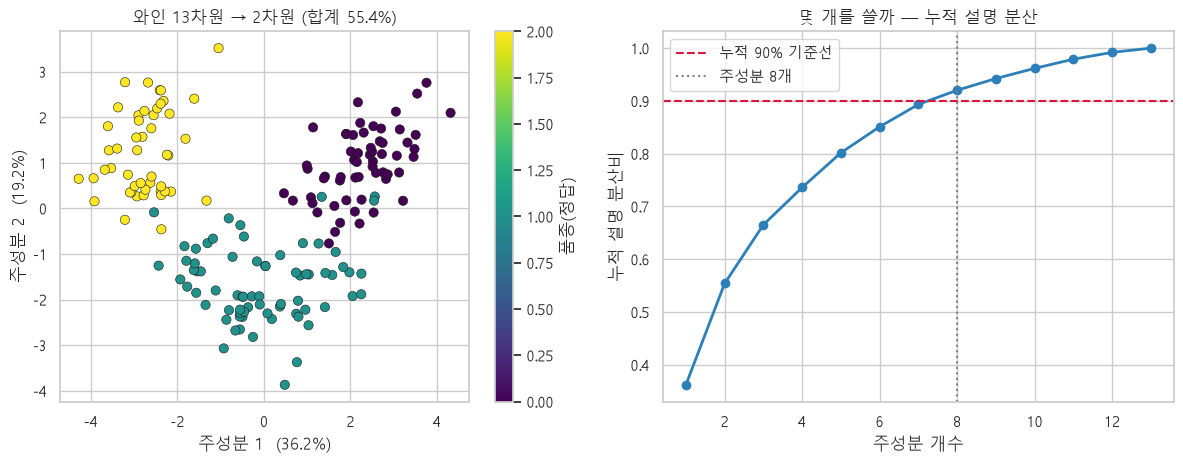

In [20]:
# ─────────────────────────────────────────────
# [C15] Part 5 · 📊 데이터로 확인해 봅시다 — 13개 피처를 2차원에
# 왼쪽: PCA 2D 산점도(품종 색) / 오른쪽: 누적 설명 분산 곡선
# ─────────────────────────────────────────────
X_pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sc = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_wine, cmap="viridis",
                     s=45, edgecolor="k", linewidth=0.4)
axes[0].set_xlabel(f"주성분 1  ({ratio[0]*100:.1f}%)")
axes[0].set_ylabel(f"주성분 2  ({ratio[1]*100:.1f}%)")
axes[0].set_title(f"와인 13차원 → 2차원 (합계 {cum[1]*100:.1f}%)")
plt.colorbar(sc, ax=axes[0], label="품종(정답)")

axes[1].plot(range(1, len(cum) + 1), cum, "o-", lw=2, color="#2c7fb8")
axes[1].axhline(0.90, color="crimson", ls="--", lw=1.5, label="누적 90% 기준선")
axes[1].axvline(n90, color="gray", ls=":", lw=1.5, label=f"주성분 {n90}개")
axes[1].set_xlabel("주성분 개수"); axes[1].set_ylabel("누적 설명 분산비")
axes[1].set_title("몇 개를 쓸까 — 누적 설명 분산")
axes[1].legend()

plt.tight_layout()
plt.show()

왼쪽 그림의 색은 PCA가 만든 군집이 아니라, 투영을 마친 뒤 비교를 위해 입힌 실제 품종 레이블입니다. PCA 학습에는 y_wine을 사용하지 않았습니다. 세 품종이 2차원에서도 어느 정도 분리된다는 사실은 투영이 품종 차이와 관련된 분산을 보존했다는 사후 신호이며, 군집화 성공을 뜻하지는 않습니다.
오른쪽 곡선은 주성분 수가 늘 때 보존되는 분산을 보여 줍니다. 시각화에는 2개를 쓰되 55.4%만 보존된 한계를 함께 적고, 모델 입력용 차원 수는 교차 검증 성능과 목적에 맞춰 정합니다.

[문제]
1) PCA를 표준화 없이 원본 X_wine에 바로 적용해, PC1의 설명 분산비를 출력해확인합니다.
2) 그 값이 표준화했을 때(0.362)와 얼마나 다른가요? 왜 그렇게 됐을까요?
   힌트가 필요하면 X_wine의 열별 분산을 함께 출력해확인합니다.
3) 이 결과는 "PCA 앞에 표준화가 필요하다"를 어떻게 뒷받침합니까?

In [ ]:
# 1) 힌트: 열별 분산 확인
print(X_wine.var().sort_values(ascending=False).round(1))

pca_raw = PCA(random_state=RANDOM_STATE).fit(X_wine)
ratio_raw = pca_raw.explained_variance_ratio_  #설명 분산비
print(f"표준화 X → PC1: {ratio_raw[0]:.3f}")



proline                         99166.7
magnesium                         204.0
alcalinity_of_ash                  11.2
color_intensity                     5.4
malic_acid                          1.2
flavanoids                          1.0
alcohol                             0.7
od280/od315_of_diluted_wines        0.5
total_phenols                       0.4
proanthocyanins                     0.3
ash                                 0.1
hue                                 0.1
nonflavanoid_phenols                0.0
dtype: float64
표준화 X → PC1: 0.998


표준화 없이 돌리면 PC1이 전체 분산의 99.8%를 차지해버려요. 거의 "1차원짜리 PCA"가 된 셈이죠.

이유는 proline 열의 분산(99166.7)이 다른 열들(대부분 0.1~10대)보다 자릿수로 압도적으로 크기 때문이에요. PCA는 "분산이 가장 큰 방향"을 PC1으로 뽑는 알고리즘이라, 단위가 안 맞으면 값이 큰 열 하나가 분산을 독점해버려요. 실제로 loading을 뽑아보면 (pca_raw.components_[0]) proline의 계수가 1.000이고 나머지는 0.02 이하 — PC1이 사실상 "proline을 그대로 베낀 축"이 돼버린 거예요.

이 결과는 "PCA 앞에 표준화가 필요하다"를 숫자로 직접 증명해줘요. PCA의 목적은 13개 성분 정보를 골고루 반영한 새 축을 찾는 건데, 표준화 없이는 그게 아니라 "어떤 열이 더 큰 숫자 단위로 측정됐는가"에만 반응하게 돼요. StandardScaler로 평균 0·표준편차 1로 맞춰야 13개 성분이 동등한 발언권을 갖고, 그제서야 PC1(0.362)이 여러 성분을 실제로 조합한 의미 있는 축이 되는 거죠.

k별 실루엣: {2: 0.64, 3: 0.72, 4: 0.513, 5: 0.407, 6: 0.402}
→ 실루엣이 가장 높은 k = 3


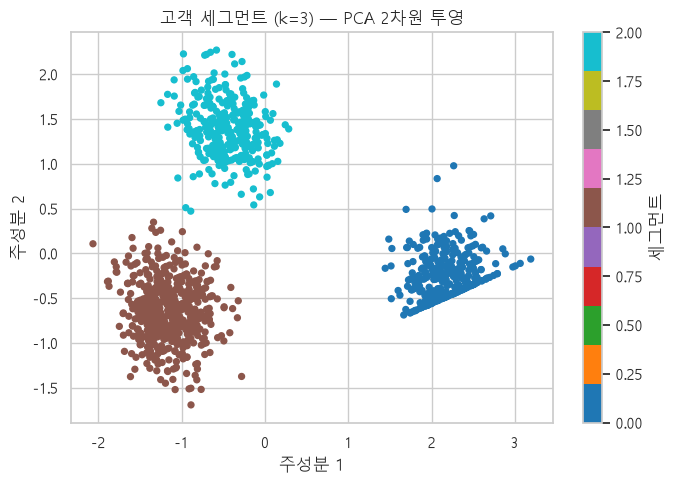


세그먼트 크기: {0: 349, 1: 539, 2: 312}


In [24]:
# ─────────────────────────────────────────────
# [C17] Part 6 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기 고객 세그먼트 찾기 — ① 스케일링 → ② k 결정 → ③ 군집화 → ④ PCA 2D
# (실행하면 k별 실루엣과 2D 산점도가 나옵니다)
# ─────────────────────────────────────────────
# ① 스케일링 — 단위가 다른 세 피처에 같은 가중치를 주기 위해 적용합니다 (시청은 시간, 세션은 회, 경과일은 일)
Xc = StandardScaler().fit_transform(cust[CUST_FEAT])

# ② k 결정 — 실루엣이 가장 높은 k
sil_k = {k: silhouette_score(Xc, KMeans(n_clusters=k, n_init=10,
                                        random_state=RANDOM_STATE).fit_predict(Xc))
         for k in range(2, 7)}
best_k = max(sil_k, key=sil_k.get)
print("k별 실루엣:", {k: round(v, 3) for k, v in sil_k.items()})
print(f"→ 실루엣이 가장 높은 k = {best_k}")

# ③ 군집화
cust["segment"] = KMeans(n_clusters=best_k, n_init=10,
                         random_state=RANDOM_STATE).fit_predict(Xc)

# ④ PCA 2D — 3차원을 2차원으로 눌러 눈으로 확인
Xc_2d = PCA(n_components=2).fit_transform(Xc)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(Xc_2d[:, 0], Xc_2d[:, 1], c=cust["segment"], cmap="tab10", s=18)
ax.set_xlabel("주성분 1"); ax.set_ylabel("주성분 2")
ax.set_title(f"고객 세그먼트 (k={best_k}) — PCA 2차원 투영")
plt.colorbar(sc, ax=ax, label="세그먼트")
plt.tight_layout(); plt.show()

print(f"\n세그먼트 크기: {cust['segment'].value_counts().sort_index().to_dict()}")

In [25]:
# ─────────────────────────────────────────────
# [C18] Part 6 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기 세그먼트 프로파일 → 페르소나 이름과 액션으로 번역
# (실행하면 프로파일 표와 세그먼트 카드가 나옵니다)
# ─────────────────────────────────────────────
profile = cust.groupby("segment")[CUST_FEAT].mean().round(1)
profile["이탈률"] = cust.groupby("segment")["churn"].mean().round(3)
profile["인원"] = cust["segment"].value_counts().sort_index()

print("=== 세그먼트 프로파일 ===")
print(profile.to_string())

# 프로파일을 읽어 페르소나와 액션을 붙입니다 (판단은 사람이 합니다)
print("\n=== 세그먼트 카드(액션은 검증할 가설) ===")
for s, row in profile.iterrows():
    if row["days_since_last_watch"] > 35:
        persona, action = "이탈 임박 휴면", "복귀 메시지 실험 후보 (효과는 별도 검증)"
    elif row["watch_hours_last_month"] > 30:
        persona, action = "충성 단골", "유지 전략 실험 후보 (효과는 별도 검증)"
    else:
        persona, action = "저관여 라이트", "취향 기반 추천 실험 후보"
    print(f"\n[세그먼트 {s}] {persona}  ({int(row['인원'])}명, 이탈률 {row['이탈률']:.1%})")
    print(f"  근거: 지난달 시청 {row['watch_hours_last_month']:.0f}시간 · "
          f"월 {row['sessions_per_month']:.1f}회 시청 · 마지막 시청 {row['days_since_last_watch']:.0f}일 전")
    print(f"  액션: {action}")

print("\n→ 번호가 아니라 '이 세그먼트는 누구인가'로 번역해야 마케팅팀이 쓸 수 있습니다.")

=== 세그먼트 프로파일 ===
         watch_hours_last_month  sessions_per_month  days_since_last_watch    이탈률   인원
segment                                                                               
0                          43.8                 9.5                    3.6  0.046  349
1                           8.8                 2.3                   19.8  0.173  539
2                          24.7                 5.4                   48.0  0.577  312

=== 세그먼트 카드(액션은 검증할 가설) ===

[세그먼트 0] 충성 단골  (349명, 이탈률 4.6%)
  근거: 지난달 시청 44시간 · 월 9.5회 시청 · 마지막 시청 4일 전
  액션: 유지 전략 실험 후보 (효과는 별도 검증)

[세그먼트 1] 저관여 라이트  (539명, 이탈률 17.3%)
  근거: 지난달 시청 9시간 · 월 2.3회 시청 · 마지막 시청 20일 전
  액션: 취향 기반 추천 실험 후보

[세그먼트 2] 이탈 임박 휴면  (312명, 이탈률 57.7%)
  근거: 지난달 시청 25시간 · 월 5.4회 시청 · 마지막 시청 48일 전
  액션: 복귀 메시지 실험 후보 (효과는 별도 검증)

→ 번호가 아니라 '이 세그먼트는 누구인가'로 번역해야 마케팅팀이 쓸 수 있습니다.


워크플로: 스케일링 → 실루엣으로 k 선택 → K-Means → PCA 2D는 시각화에만 사용 → 프로파일로 비즈니스 라벨. 

결과: 고객이 "VIP / 이탈위험 / 일반" 같은 행동 가능한 그룹으로 나뉨. 각 그룹에 대한 서로 다른 마케팅 가설(VIP 리텐션, 이탈위험 재유치)을 설계할 수 있음. 

검증(정답 없음): 실루엣 점수(통계) + 프로파일이 비즈니스적으로 말이 되는가(해석)로 함께 판단. 마케팅팀과 라벨을 검토해 확정.

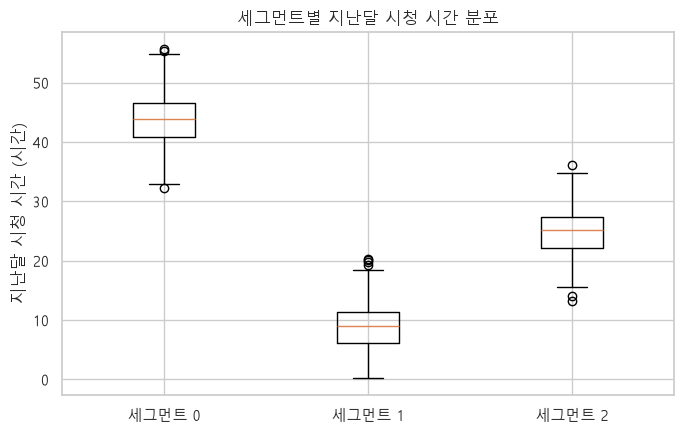

→ 평균만 보면 놓치는 것이 보입니다 — 각 세그먼트 안에서도 편차가 있습니다.


In [26]:
# ─────────────────────────────────────────────
# [C19] Part 5 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기
# 세그먼트별 지난달 시청 시간 분포 (실행하면 박스플롯이 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
data_by_seg = [cust.loc[cust["segment"] == s, "watch_hours_last_month"].values
               for s in sorted(cust["segment"].unique())]
ax.boxplot(data_by_seg, tick_labels=[f"세그먼트 {s}" for s in sorted(cust["segment"].unique())])
ax.set_ylabel("지난달 시청 시간 (시간)")
ax.set_title("세그먼트별 지난달 시청 시간 분포")
plt.tight_layout()
plt.show()

print("→ 평균만 보면 놓치는 것이 보입니다 — 각 세그먼트 안에서도 편차가 있습니다.")

In [27]:
# ─────────────────────────────────────────────
# [C20] Part 7 · 📊 데이터로 확인해 봅시다 — 같은 표현으로 세 방식을 비교
# 군집 중심거리 피처 3방 비교 (실행하면 F1 평균과 차이가 출력됩니다)
# ─────────────────────────────────────────────
X_cust = cust[CUST_FEAT]
y_cust = cust["churn"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def lr():
    return LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

# ① 군집 파생 피처 없음
plain = Pipeline([("scale", StandardScaler()), ("clf", lr())])
s_plain = cross_val_score(plain, X_cust, y_cust, cv=cv, scoring="f1")

# ② Pipeline 안 KMeans — 각 겹의 학습 조각에서만 중심을 fit
feat = FeatureUnion([
    ("original", "passthrough"),
    ("cluster_distance", KMeans(n_clusters=3, n_init=10,
                                random_state=RANDOM_STATE)),
])
inside = Pipeline([("scale", StandardScaler()), ("feat", feat), ("clf", lr())])
s_inside = cross_val_score(inside, X_cust, y_cust, cv=cv, scoring="f1")

# ③ 전체 데이터로 스케일러·KMeans fit → 같은 중심거리 표현 생성 (누수)
scaler_all = StandardScaler().fit(X_cust)
X_scaled_all = scaler_all.transform(X_cust)
km_all = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_scaled_all)
X_leak = np.column_stack([X_scaled_all, km_all.transform(X_scaled_all)])
s_leak = cross_val_score(lr(), X_leak, y_cust, cv=cv, scoring="f1")

print("이탈 예측 F1 (층화 5겹 교차 검증)")
print(f"  ① 군집 파생 피처 없음         {s_plain.mean():.4f} ± {s_plain.std():.4f}")
print(f"  ② Pipeline 안 중심거리 (정상) {s_inside.mean():.4f} ± {s_inside.std():.4f}"
      f"   변화 {s_inside.mean() - s_plain.mean():+.4f}")
print(f"  ③ 전체-fit 중심거리 (누수)    {s_leak.mean():.4f} ± {s_leak.std():.4f}"
      f"   변화 {s_leak.mean() - s_plain.mean():+.4f}")
print()
print(f"→ 관측된 파생 피처 효과 (② − ①) {s_inside.mean() - s_plain.mean():+.4f}")
print(f"  전체-fit과 정상 절차 차이 (③ − ②) {s_leak.mean() - s_inside.mean():+.4f}")

이탈 예측 F1 (층화 5겹 교차 검증)
  ① 군집 파생 피처 없음         0.4751 ± 0.0302
  ② Pipeline 안 중심거리 (정상) 0.5125 ± 0.0513   변화 +0.0374
  ③ 전체-fit 중심거리 (누수)    0.5116 ± 0.0434   변화 +0.0365

→ 관측된 파생 피처 효과 (② − ①) +0.0374
  전체-fit과 정상 절차 차이 (③ − ②) -0.0009


[문제]
군집 수를 바꾸면 피처화 효과가 어떻게 달라지는지 확인합니다.

1) [C20]의 ② 방식(Pipeline 안 KMeans)을 k = 2, 3, 4, 5로 각각 돌려
   F1 평균을 표로 출력합니다.
2) 어느 k에서 효과가 가장 컸습니까? 그 값이 Part 6에서 실루엣이 고른 k와 같습니까?
3) 결과를 보고 "피처화용 k와 해석용 k가 같아야 하는가"에 한 줄로 답합니다.

In [29]:
# [C21] Part 7 · ⌨️ 백문이 불여일타! (5)
# ⌨️ 백문이 불여일타! (5) — 군집 수(k)에 따른 피처화 효과

k_values = [2, 3, 4, 5]

# 여기에 코드를 작성하세요
# k=2,3,4,5로 ② 방식 반복
rows = []
for k in k_values:
    feat_k = FeatureUnion([
        ("original", "passthrough"),
        ("cluster_distance", KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)),
    ])
    pipe_k = Pipeline([("scale", StandardScaler()), ("feat", feat_k), ("clf", lr())])
    s_k = cross_val_score(pipe_k, X_cust, y_cust, cv=cv, scoring="f1")
    rows.append({"k": k, "F1_mean": s_k.mean(), "F1_std": s_k.std(),
                 "효과(-①)": s_k.mean() - s_plain.mean()})

result_table = pd.DataFrame(rows).set_index("k").round(4)
result_table

,F1_mean,F1_std,효과(-①)
k,,,
2,0.4774,0.0289,0.0023
3,0.5125,0.0513,0.0374
4,0.5169,0.0485,0.0418
5,0.5206,0.0563,0.0455


2) 효과가 가장 큰 건 k=5
3) 같지 않음. 해석용 k는 "사람이 이해하기 쉬운 자연스러운 세그먼트 수"를 찾는 것이고, 피처화용 k는 "다운스트림 모델 성능을 최대화하는 표현"을 찾는 것이라 애초에 목적이 다릅니다.